<div style="text-align: center;">

# Scientific Programming with Python
## Homework 6: Matplotlib/Seaborn and Data Visualization

<center>

### **Author:** 2026SS_41
### **Date:** July 3, 2026

</center>
</div>

---

**Goal:** Explore solar power generation and weather data from two solar power plants [1] using NumPy [2], Matplotlib [3], and Pandas [4], in order to practice the data visualization concepts covered in lecture so far.

**Dataset:** `solar_combined.csv` — a combined, plant-level dataset (6,416 rows) built from the original 4 raw files (2 plants x generation + weather), with the 22 inverters per plant aggregated to one row per 15-minute timestamp. Columns: `PLANT`, `DATE_TIME`, `DC_POWER`, `AC_POWER`, `DAILY_YIELD`, `AMBIENT_TEMPERATURE`, `MODULE_TEMPERATURE`, `IRRADIATION`.

**Task 1:** Data overview.  
**Task 2:** Descriptive statistics.  
**Task 3:** Time series and moving average.  
**Task 4:** Histograms.  
**Task 5:** Factorizing and color-coded scatter plot.  
**Task 6:** Correlation analysis.  
**Task 7:** Polynomial fitting.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from numpy.polynomial import Polynomial

---

## Task 1: Data Overview

The combined dataset is loaded, and `DATE_TIME` is converted to a proper datetime type. The data is then split by `PLANT` into two `DataFrames`, using Pandas' boolean filtering [4], for a per-plant exploration.

**Note on units:** the original dataset [1] does not explicitly document units for `AC_POWER`/`DC_POWER` or `IRRADIATION`. Based on common convention for this type of solar-plant monitoring data, `AC_POWER`/`DC_POWER` are assumed to be in kW and `IRRADIATION` in kW/m². These are reasonable assumptions, but they are not stated in the original source.

In [3]:
solar_data = pd.read_csv('solar_combined.csv')
solar_data['DATE_TIME'] = pd.to_datetime(solar_data['DATE_TIME'])

print(f'Shape: {solar_data.shape}')
print()
solar_data.head()

Shape: (6416, 8)



,PLANT,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,Plant_1,2020-05-15 00:00:00,0.0,0.0,0.0,25.184316,22.857507,0.0
1,Plant_1,2020-05-15 00:15:00,0.0,0.0,0.0,25.084589,22.761668,0.0
2,Plant_1,2020-05-15 00:30:00,0.0,0.0,0.0,24.935753,22.592306,0.0
3,Plant_1,2020-05-15 00:45:00,0.0,0.0,0.0,24.846130,22.360852,0.0
4,Plant_1,2020-05-15 01:00:00,0.0,0.0,0.0,24.621525,22.165423,0.0


In [4]:
plant_1 = solar_data[solar_data['PLANT'] == 'Plant_1']
plant_2 = solar_data[solar_data['PLANT'] == 'Plant_2']

print(f'Plant 1 rows: {len(plant_1)}')
print(f'Plant 2 rows: {len(plant_2)}')

Plant 1 rows: 3157
Plant 2 rows: 3259


---

## Task 2: Descriptive Statistics

The mean and sample standard deviation (`ddof=1`) of `AC_POWER` are computed for each plant by looping over a dictionary mapping plant names to their `DataFrames`, and displayed as a Matplotlib bar plot [3] with error bars (`yerr`).

In [5]:
plants_data = {'Plant 1': plant_1, 'Plant 2': plant_2}

ac_power_stats = {}

for plant_name, plant_df in plants_data.items():
    mean_power = plant_df['AC_POWER'].mean()
    std_power = plant_df['AC_POWER'].std(ddof=1)

    ac_power_stats[plant_name] = {'mean': mean_power, 'std': std_power}

    print(f'{plant_name} AC Power: {mean_power:.1f} ± {std_power:.1f} kW')

Plant 1 AC Power: 6704.8 ± 8604.2 kW
Plant 2 AC Power: 5012.0 ± 6317.9 kW


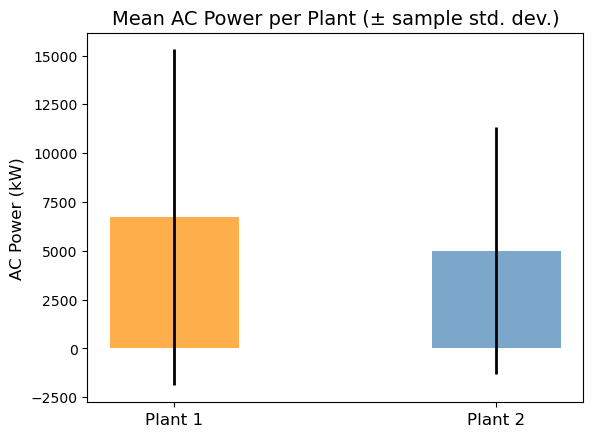

In [6]:
plant_names = list(ac_power_stats.keys())
means = [ac_power_stats[name]['mean'] for name in plant_names]
stds = [ac_power_stats[name]['std'] for name in plant_names]
x_positions = np.arange(len(plant_names))

plt.bar(x=x_positions, height=means, width=0.4,
        color=['darkorange', 'steelblue'], alpha=0.7,
        yerr=stds, error_kw={'ecolor': 'black', 'elinewidth': 2})

plt.xticks(ticks=x_positions, labels=plant_names, fontsize=12)
plt.ylabel(ylabel='AC Power (kW)', fontsize=12)
plt.title(label='Mean AC Power per Plant (± sample std. dev.)', fontsize=14)

plt.show()

Plant 1 shows both a higher mean AC power output and a larger spread (std. dev.) than Plant 2 across the recorded period.

---

## Task 3: Time Series and Moving Average

`AC_POWER` is plotted over time for Plant 1 using Matplotlib [3], together with a 1-hour moving average (a 4-sample rolling window, since data is recorded every 15 minutes), computed via Pandas' `.rolling()` function [4]. A 1-hour window is chosen as a balance: short enough to preserve the shape of the daily on/off solar cycle, but long enough to smooth out sensor noise between consecutive 15-minute readings.

In [7]:
plant_1_sorted = plant_1.sort_values(by='DATE_TIME')

plant_1_sorted = plant_1_sorted.copy()
plant_1_sorted['AC_POWER_MOVING_AVG'] = plant_1_sorted['AC_POWER'].rolling(window=4, win_type=None).mean()

plant_1_sorted[['DATE_TIME', 'AC_POWER', 'AC_POWER_MOVING_AVG']].head()

,DATE_TIME,AC_POWER,AC_POWER_MOVING_AVG
0,2020-05-15 00:00:00,0.0,NaN
1,2020-05-15 00:15:00,0.0,NaN
2,2020-05-15 00:30:00,0.0,NaN
3,2020-05-15 00:45:00,0.0,0.0
4,2020-05-15 01:00:00,0.0,0.0


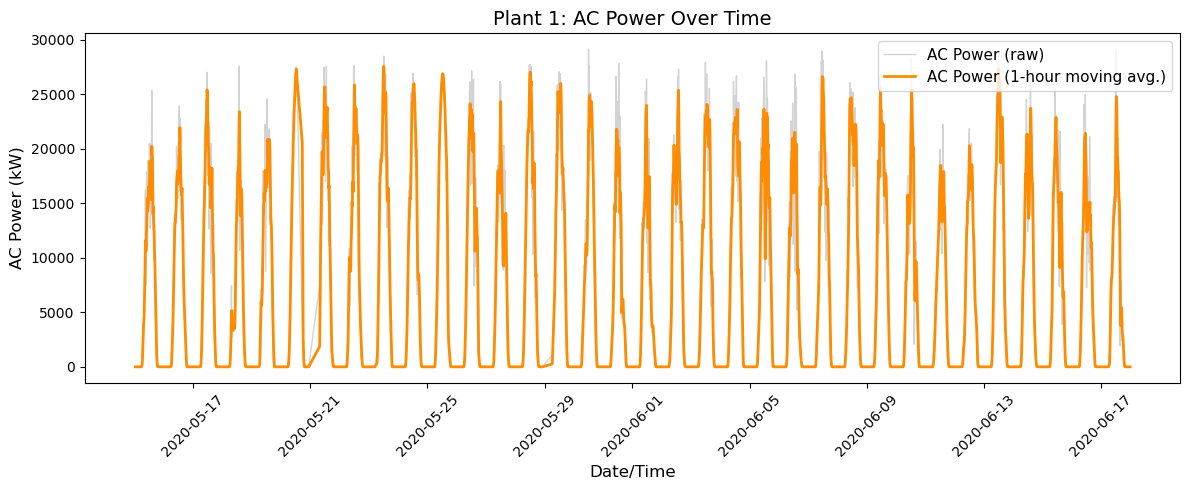

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(plant_1_sorted['DATE_TIME'], plant_1_sorted['AC_POWER'],
         color='lightgray', linewidth=1, label='AC Power (raw)')

plt.plot(plant_1_sorted['DATE_TIME'], plant_1_sorted['AC_POWER_MOVING_AVG'],
         color='darkorange', linewidth=2, label='AC Power (1-hour moving avg.)')

plt.xlabel(xlabel='Date/Time', fontsize=12)
plt.ylabel(ylabel='AC Power (kW)', fontsize=12)
plt.title(label='Plant 1: AC Power Over Time', fontsize=14)

plt.xticks(rotation=45)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

The daily on/off solar cycle is clearly visible, and the moving average smooths out the short-term (15-minute-to-15-minute) fluctuations, making the overall daily pattern easier to see.

---

## Task 4: Histograms

The distribution of `IRRADIATION` values (kW/m²) is plotted for each plant using Matplotlib's `.hist()` function [3], overlaid using transparency (`alpha`).

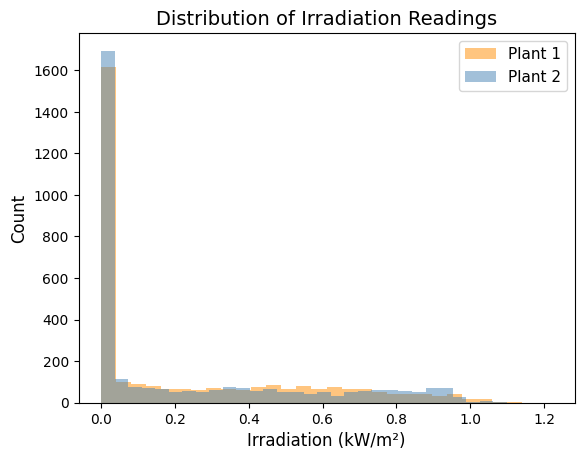

In [8]:
plt.hist(plant_1['IRRADIATION'], bins=30, color='darkorange', alpha=0.5, label='Plant 1')
plt.hist(plant_2['IRRADIATION'], bins=30, color='steelblue', alpha=0.5, label='Plant 2')

plt.xlabel(xlabel='Irradiation (kW/m²)', fontsize=12)
plt.ylabel(ylabel='Count', fontsize=12)
plt.title(label='Distribution of Irradiation Readings', fontsize=14)

plt.legend(loc='upper right', fontsize=11)

plt.show()

Both plants show a strong peak at (or near) zero irradiation, corresponding to nighttime readings, with the remaining values spread across the daylight hours.

---

## Task 5: Factorizing and a Color-Coded Scatter Plot

The categorical `PLANT` column is converted into numeric codes using Pandas' `.factorize()` function [4]. These codes are then used with a Matplotlib qualitative colormap [3] to color-code a scatter plot of `AC_POWER` vs. `IRRADIATION` by plant.

In [9]:
plant_codes, plant_uniques = solar_data['PLANT'].factorize()

print(f'Unique plants : {list(plant_uniques)}')
print(f'First 5 codes : {plant_codes[:5]}')
print(f'Last 5 codes  : {plant_codes[-5:]}')

Unique plants : ['Plant_1', 'Plant_2']
First 5 codes : [0 0 0 0 0]
Last 5 codes  : [1 1 1 1 1]


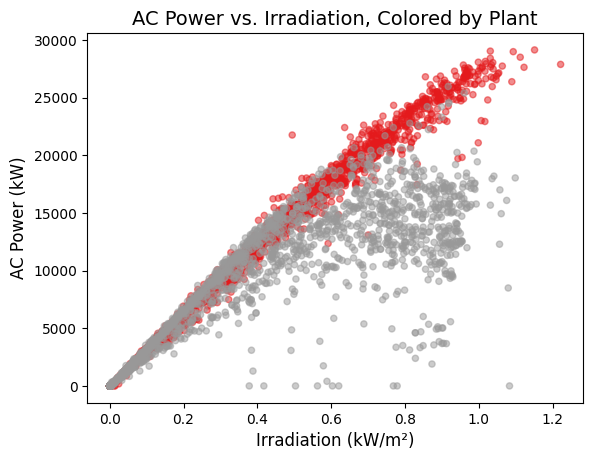

In [10]:
plt.scatter(solar_data['IRRADIATION'], solar_data['AC_POWER'],
            c=plant_codes, cmap=plt.cm.Set1, alpha=0.5, s=20)

plt.xlabel(xlabel='Irradiation (kW/m²)', fontsize=12)
plt.ylabel(ylabel='AC Power (kW)', fontsize=12)
plt.title(label='AC Power vs. Irradiation, Colored by Plant', fontsize=14)

plt.show()

As expected, `AC_POWER` increases with `IRRADIATION`. The color-coding (qualitative colormap, since `PLANT` has no inherent ordering) shows that Plant 1 (one color) reaches noticeably higher AC power values than Plant 2 (the other color) at comparable irradiation levels.

---

## Task 6: Correlation Analysis

Pandas' `.corr()` function [4] is used to compute the pairwise correlation between the numeric columns of interest.

In [9]:
correlation_columns = ['AC_POWER', 'DC_POWER', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

correlation_matrix = solar_data[correlation_columns].corr()
correlation_matrix

,AC_POWER,DC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
AC_POWER,1.000000,0.797230,0.593164,0.903046,0.938184
DC_POWER,0.797230,1.000000,0.271066,0.629020,0.650191
AMBIENT_TEMPERATURE,0.593164,0.271066,1.000000,0.818020,0.654558
MODULE_TEMPERATURE,0.903046,0.629020,0.818020,1.000000,0.950708
IRRADIATION,0.938184,0.650191,0.654558,0.950708,1.000000


In [10]:
plant_1_dc_ac_corr = plant_1['AC_POWER'].corr(plant_1['DC_POWER'])
plant_2_dc_ac_corr = plant_2['AC_POWER'].corr(plant_2['DC_POWER'])

print(f'Plant 1 AC-DC correlation: {plant_1_dc_ac_corr:.6f}')
print(f'Plant 2 AC-DC correlation: {plant_2_dc_ac_corr:.6f}')

Plant 1 AC-DC correlation: 0.999997
Plant 2 AC-DC correlation: 0.999996


`AC_POWER` correlates most strongly with `IRRADIATION` and `MODULE_TEMPERATURE`, which makes physical sense: more sunlight (irradiation) both generates more power directly and heats up the panels (module temperature). `AMBIENT_TEMPERATURE` correlates more weakly, since it is affected by more than just direct sunlight (e.g., weather conditions).

One result above looks surprising at first: the pooled `AC_POWER`-`DC_POWER` correlation is only about 0.80, even though an inverter's AC output should track its DC input almost perfectly. Computing the correlation separately per plant (below) resolves this — each plant individually shows an AC-DC correlation of essentially 1.0 (0.999997 for Plant 1 and 0.999996 for Plant 2). The discrepancy is not a weak physical relationship; it is a scaling difference between plants. Plant 1's average DC/AC ratio is roughly 10x, versus roughly 1x for Plant 2, likely due to how each plant's DC meter reports its readings. Pooling both plants together before computing the correlation mixes these two different scales, which artificially lowers the combined correlation coefficient — a useful reminder to check subgroups before trusting a pooled statistic.

---

## Task 7: Polynomial Fitting

A 2nd-degree polynomial is fit to Plant 1's `AC_POWER` as a function of `IRRADIATION` using NumPy's `Polynomial.fit` [2]. A 2nd-degree fit is chosen because the relationship is expected to be monotonically increasing but slightly saturating at high irradiation (e.g., due to inverter clipping and temperature-related efficiency losses): a straight line (degree 1) could not capture this curvature, while a higher degree risks overfitting the moderate amount of data available for a single plant. As `Polynomial.fit` internally scales the x-data to a [−1, 1] window, `.convert().coef` is used to retrieve the coefficients in the original coordinate system. The fit is then plotted over the raw data using Matplotlib [3].

In [11]:
irradiation_values = plant_1['IRRADIATION'].values
ac_power_values = plant_1['AC_POWER'].values

fitted_poly = Polynomial.fit(irradiation_values, ac_power_values, deg=2)
fitted_coefficients = fitted_poly.convert().coef

print('Fitted polynomial (scaled window):')
print(fitted_poly)
print()
print(f'Fitted coefficients (unscaled) : {fitted_coefficients}')

Fitted polynomial (scaled window):
17934.76970592 + 15703.13311813 (-1.0 + 1.63712764x) -
2282.83210652 (-1.0 + 1.63712764x)**2

Fitted coefficients (unscaled) : [  -51.19551872 33182.6082635  -6118.41670046]


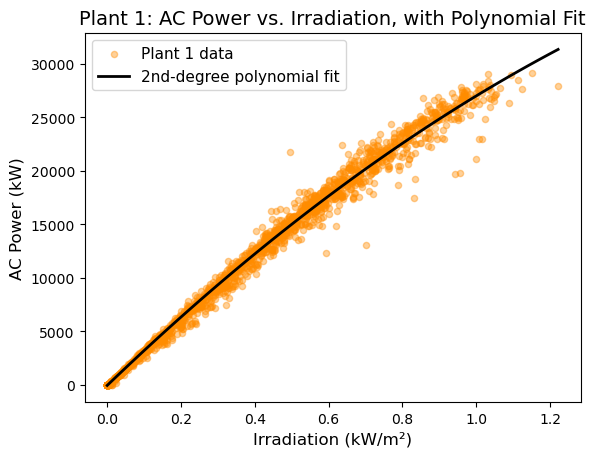

In [12]:
x_fit = np.linspace(irradiation_values.min(), irradiation_values.max(), num=100)
y_fit = fitted_poly(x_fit)

plt.scatter(irradiation_values, ac_power_values,
            color='darkorange', alpha=0.4, s=20, label='Plant 1 data')

plt.plot(x_fit, y_fit, color='black', linewidth=2, label='2nd-degree polynomial fit')

plt.xlabel(xlabel='Irradiation (kW/m²)', fontsize=12)
plt.ylabel(ylabel='AC Power (kW)', fontsize=12)
plt.title(label='Plant 1: AC Power vs. Irradiation, with Polynomial Fit', fontsize=14)

plt.legend(loc='upper left', fontsize=11)

plt.show()

The fitted 2nd-degree polynomial captures the overall increasing, slightly saturating relationship between irradiation and AC power output. The scatter around the fit reflects real-world variation (e.g., panel condition, temperature effects, and inverter differences) that a single smooth curve cannot fully capture.

---

### **References**

[1] Kannal, A. Solar Power Generation Data. Kaggle. Available at https://www.kaggle.com/datasets/anikannal/solar-power-generation-data. Online; accessed July 3, 2026.

[2] Harris, C.R., Millman, K.J., van der Walt, S.J. et al. Array programming with NumPy. Nature, 585 (2020) 357–362 (DOI: 10.1038/s41586-020-2649-2).

[3] Hunter, J.D., 2007. Matplotlib: A 2D graphics environment. IEEE Annals of the History of Computing, 9(03), pp.90-95.

[4] The pandas development team, pandas-dev/pandas: Pandas, Zenodo, 2020, https://doi.org/10.5281/zenodo.3509134. Online; accessed July 3, 2026.

[5] Python Software Foundation. Python Language Reference, version 3.14. Available at http://www.python.org. Online; accessed July 3, 2026.

[6] Kluyver, T., Ragan-Kelley, B., Pérez, F. et al. Jupyter Notebooks – a publishing format for reproducible computational workflows. In F. Loizides & B. Schmidt, eds. Positioning and Power in Academic Publishing: Players, Agents and Agendas. IOS Press, 2016, pp. 87–90.